# PCA

# Concepts Learned
1. PCA
    * A Way of projecting higher dimesions on 2d. Really cool.
2. Curse of Dimensionality
    * The More dimesions you have, the data needed to accurately fit a model increases expotentially

🚩
Deliverable: On a dataset with 10+ features: fit PCA on the standardized data, plot the cumulative explained variance curve, and mark the number of components needed for 95% variance. Then go back to your Week 8 SVM and re-train it on a 2-component PCA projection — plot the decision boundary on that projection and compare against the raw-feature version.

In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv("Deliverable #8\ccf.csv").drop(columns=["Time"])
df.head()

,V1,V2,V3,V4,V5,Amount,Class
0,-2.289061,-1.313758,-0.452562,-0.392802,0.224787,1600.89,0
1,1.432482,-1.095302,-0.129910,-1.362911,-1.017335,4191.85,0
2,1.214722,-0.168797,0.581433,0.699020,0.964415,3271.32,0
3,-0.880864,0.110956,-0.203236,-0.243510,0.362543,1377.51,0
4,-0.881879,0.786970,1.110118,0.015365,-1.135162,4838.72,0


In [3]:
from pandas import col


X = df.drop(columns=['Class'])
y = df["Class"]

<Axes: xlabel='Class', ylabel='Count'>

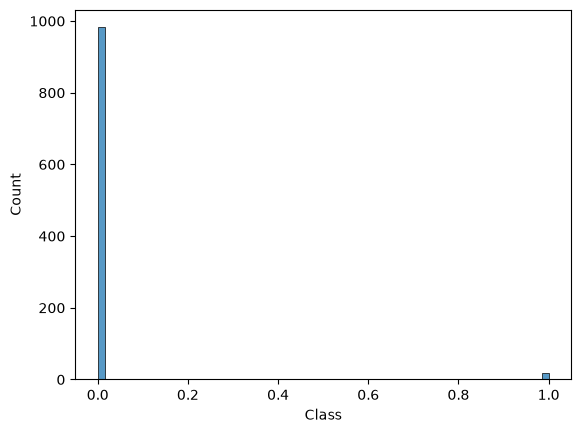

In [33]:
sns.histplot(y)

In [35]:
len(y[y==1]), len(y[y==0])

(18, 982)

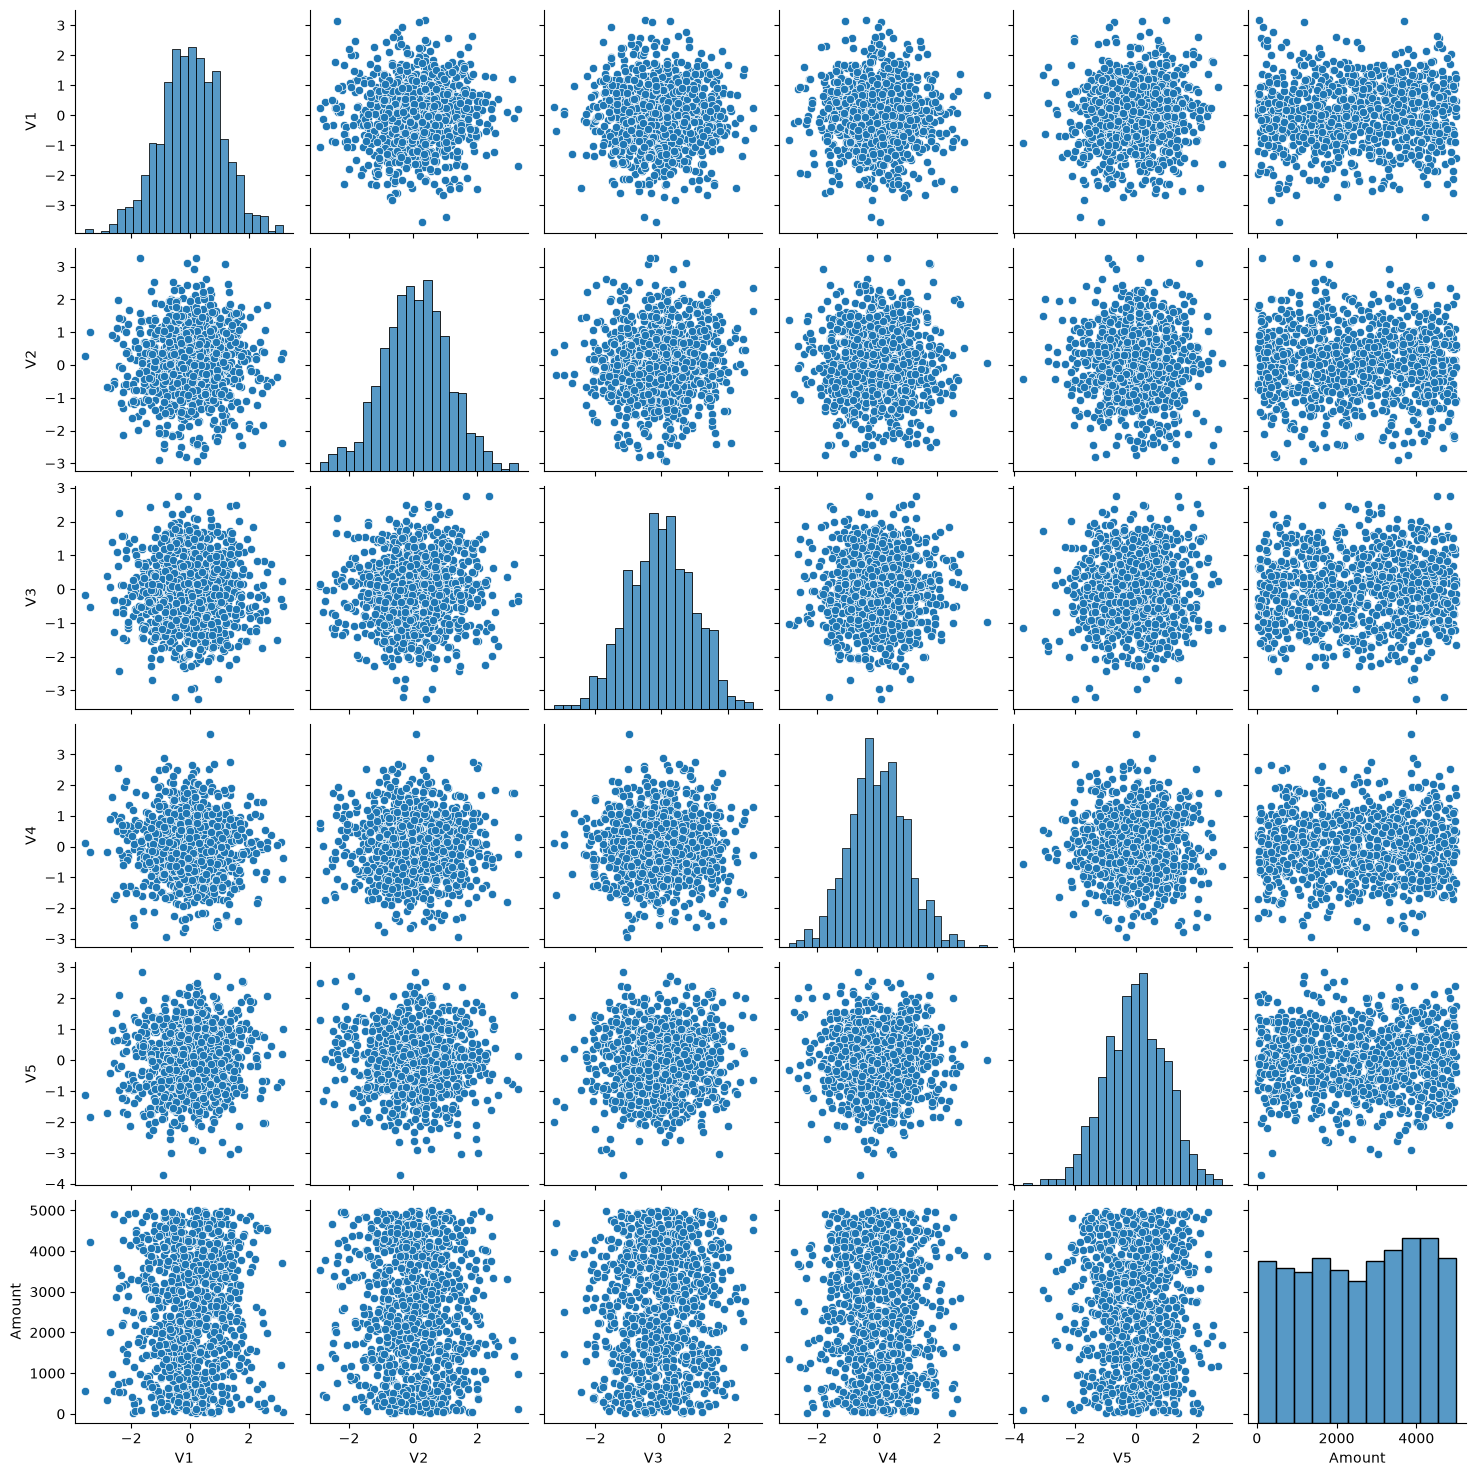

In [4]:
sns.pairplot(X)

In [23]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

In [6]:
X = StandardScaler().fit_transform(X)

In [7]:
X_train, X_test, y_train, y_test  = train_test_split(X, y, shuffle=True, test_size=0.2)
len(X_train), len(X_test)

(800, 200)

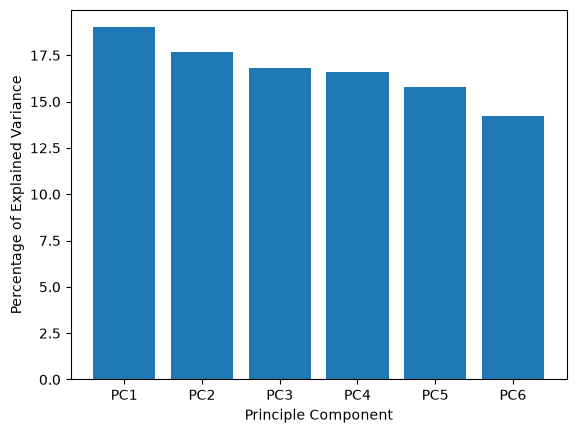

In [18]:
pca2 = PCA(0.95)
pca1_values = pca2.fit_transform(X=X_train)
per_var = np.round(pca2.explained_variance_ratio_*100, decimals=1)
lables = ["PC" + str(x) for x in range(1, len(per_var)+1)]


plt.bar(x=range(1, len(per_var)+1), height=per_var)
plt.ylabel("Percentage of Explained Variance")
plt.xlabel("Principle Component")
plt.xticks(range(1, len(per_var)+1), labels=lables)
plt.show()

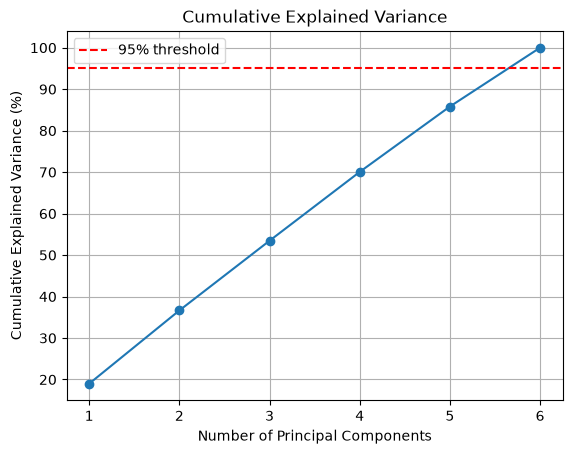

In [19]:
cum_var = np.cumsum(pca2.explained_variance_ratio_) * 100

plt.plot(range(1, len(cum_var)+1), cum_var, marker='o')
plt.ylabel("Cumulative Explained Variance (%)")
plt.xlabel("Number of Principal Components")
plt.title("Cumulative Explained Variance")
plt.axhline(y=95, color='r', linestyle='--', label='95% threshold')  # optional reference line
plt.legend()
plt.grid(True)
plt.show()


In [38]:


pipeline = Pipeline([
    ("scaling", StandardScaler()),
    ("PCA", PCA(n_components=3)),
    ("Model", SVC())
])

params = {
    "Model__C": [0.1,1,10,100],
    "Model__gamma": [0.1,1,10,100]
}


gs = GridSearchCV(
    estimator=pipeline,
    param_grid=params,
    cv=5,
    scoring="accuracy"
) 



In [39]:
gs.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...del', SVC())])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'Model__C': [0.1, 1, ...], 'Model__gamma': [0.1, 1, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity of info

In [40]:
gs.best_estimator_, gs.best_score_

(Pipeline(steps=[('scaling', StandardScaler()), ('PCA', PCA(n_components=3)),
                 ('Model', SVC(C=0.1, gamma=0.1))]),
 np.float64(0.98375))

In [37]:
y_pred = gs.best_estimator_.predict(X_test)
accuracy_score(y_test, y_pred)

0.975

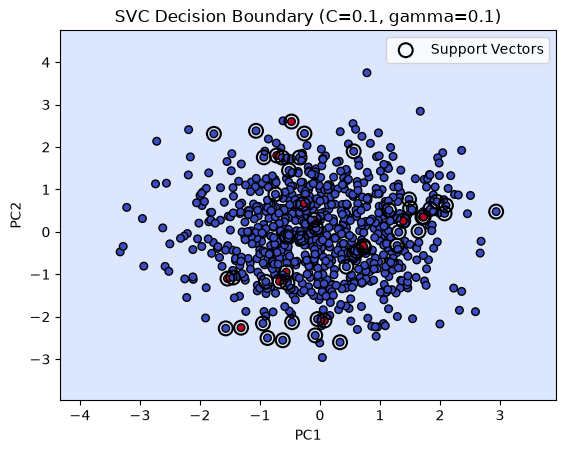

In [ ]:
best_pipeline = gs.best_estimator_
scaler = best_pipeline.named_steps["scaling"]
pca = best_pipeline.named_steps["PCA"]
svc = best_pipeline.named_steps["Model"]

X_train_scaled = scaler.transform(X_train)
X_train_pca = pca.transform(X_train_scaled)

x_min, x_max = X_train_pca[:, 0].min() - 1, X_train_pca[:, 0].max() + 1
y_min, y_max = X_train_pca[:, 1].min() - 1, X_train_pca[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

Z = svc.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.3, cmap="coolwarm")

plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1],
            c=y_train, cmap="coolwarm", edgecolors="k", s=30)

plt.scatter(svc.support_vectors_[:, 0], svc.support_vectors_[:, 1],
            s=100, facecolors="none", edgecolors="black", linewidths=1.5,
            label="Support Vectors")

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title(f"SVC Decision Boundary (C={svc.C}, gamma={svc.gamma})")
plt.legend()
plt.show()